# Upper PPO Training Analysis
**Reward mode:** `paper_cost_target_delta`  
**Scenario:** `jain_balance_controllable`  
Auto-loads the most recent run in `models/upper_ppo_3gnb/`.

In [1]:
import json, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── auto-select latest run ──────────────────────────────────────────────────
BASE = 'models/upper_ppo_3gnb'
runs = sorted(glob.glob(f'{BASE}/run_*'))
RUN  = runs[-1]
print('Run:', RUN)

df  = pd.read_csv(f'{RUN}/training_log.csv')
cfg = json.load(open(f'{RUN}/config.json'))

print(f'Steps: {len(df):,}   Columns: {len(df.columns)}')
print(f'Reward mode: {cfg.get("upper_reward_mode")}   Scenario: {cfg.get("single_training_scenario")}')

Run: models/upper_ppo_3gnb/run_20260627_001304


Steps: 45,460   Columns: 276
Reward mode: paper_cost_target_delta   Scenario: jain_balance_controllable


## 1 · Reward curves

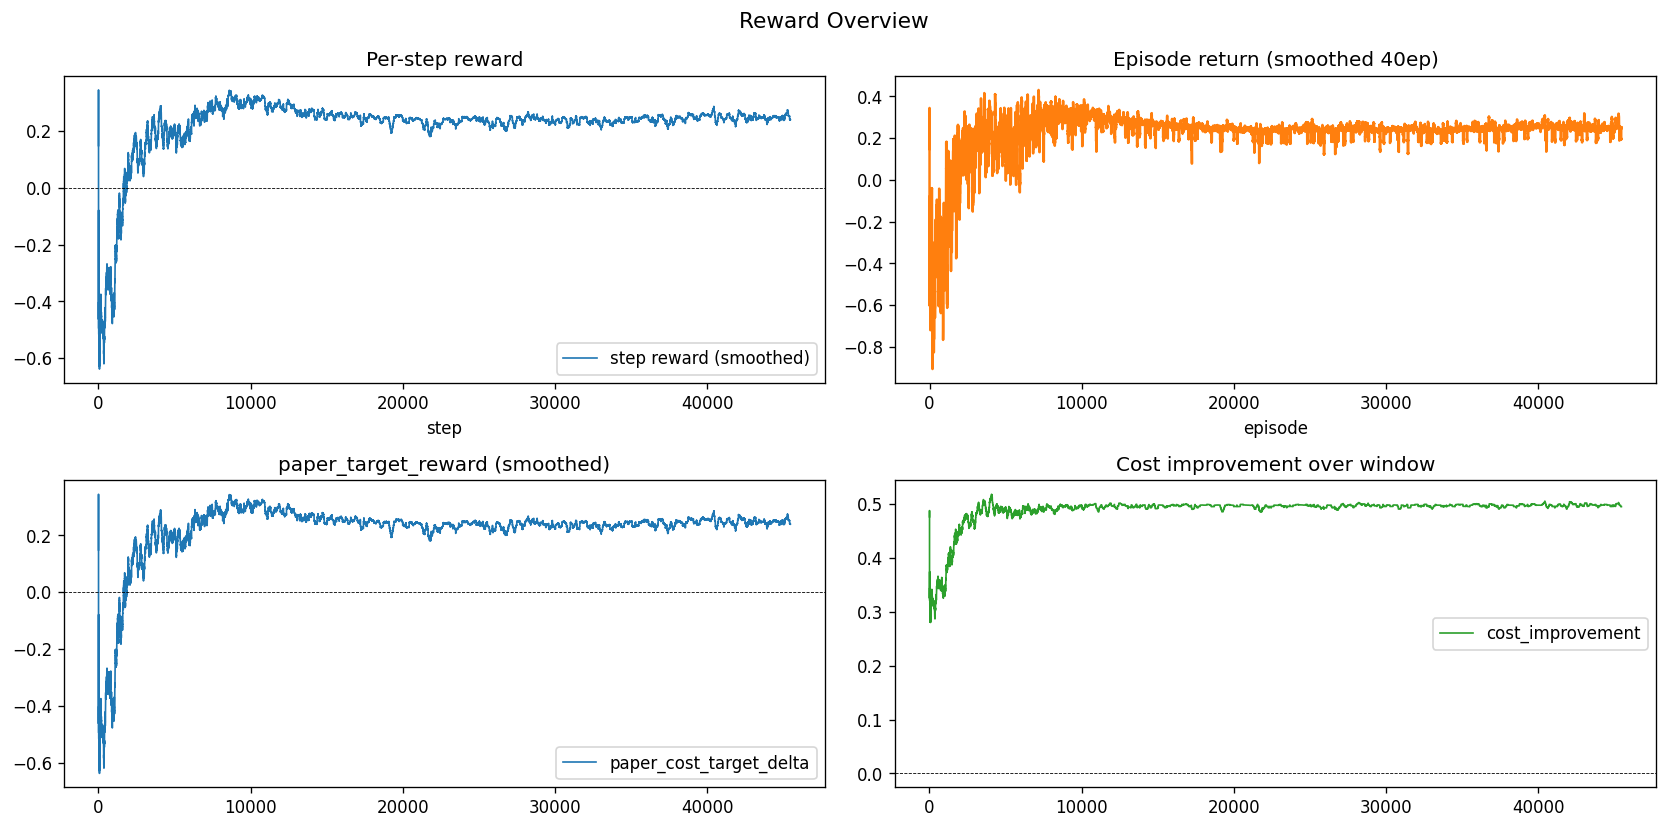

In [2]:
def smooth(s, w=200): return s.rolling(w, min_periods=1).mean()

# Episode-level returns
ep = df[df['done'] == 1].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle('Reward Overview', fontsize=13)

ax = axes[0, 0]
ax.plot(df['step'], smooth(df['reward']), lw=1, label='step reward (smoothed)')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_title('Per-step reward'); ax.set_xlabel('step'); ax.legend()

ax = axes[0, 1]
ax.plot(ep['episode'], smooth(ep['episode_return'], 40), lw=1.5, color='C1')
ax.set_title('Episode return (smoothed 40ep)'); ax.set_xlabel('episode')

ax = axes[1, 0]
ax.plot(df['step'], smooth(df['paper_target_reward']), lw=1, label='paper_cost_target_delta')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_title('paper_target_reward (smoothed)'); ax.legend()

ax = axes[1, 1]
ax.plot(df['step'], smooth(df['paper_target_cost_improvement']), lw=1, color='C2', label='cost_improvement')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_title('Cost improvement over window'); ax.legend()

plt.tight_layout(); plt.show()

## 2 · Reward component breakdown

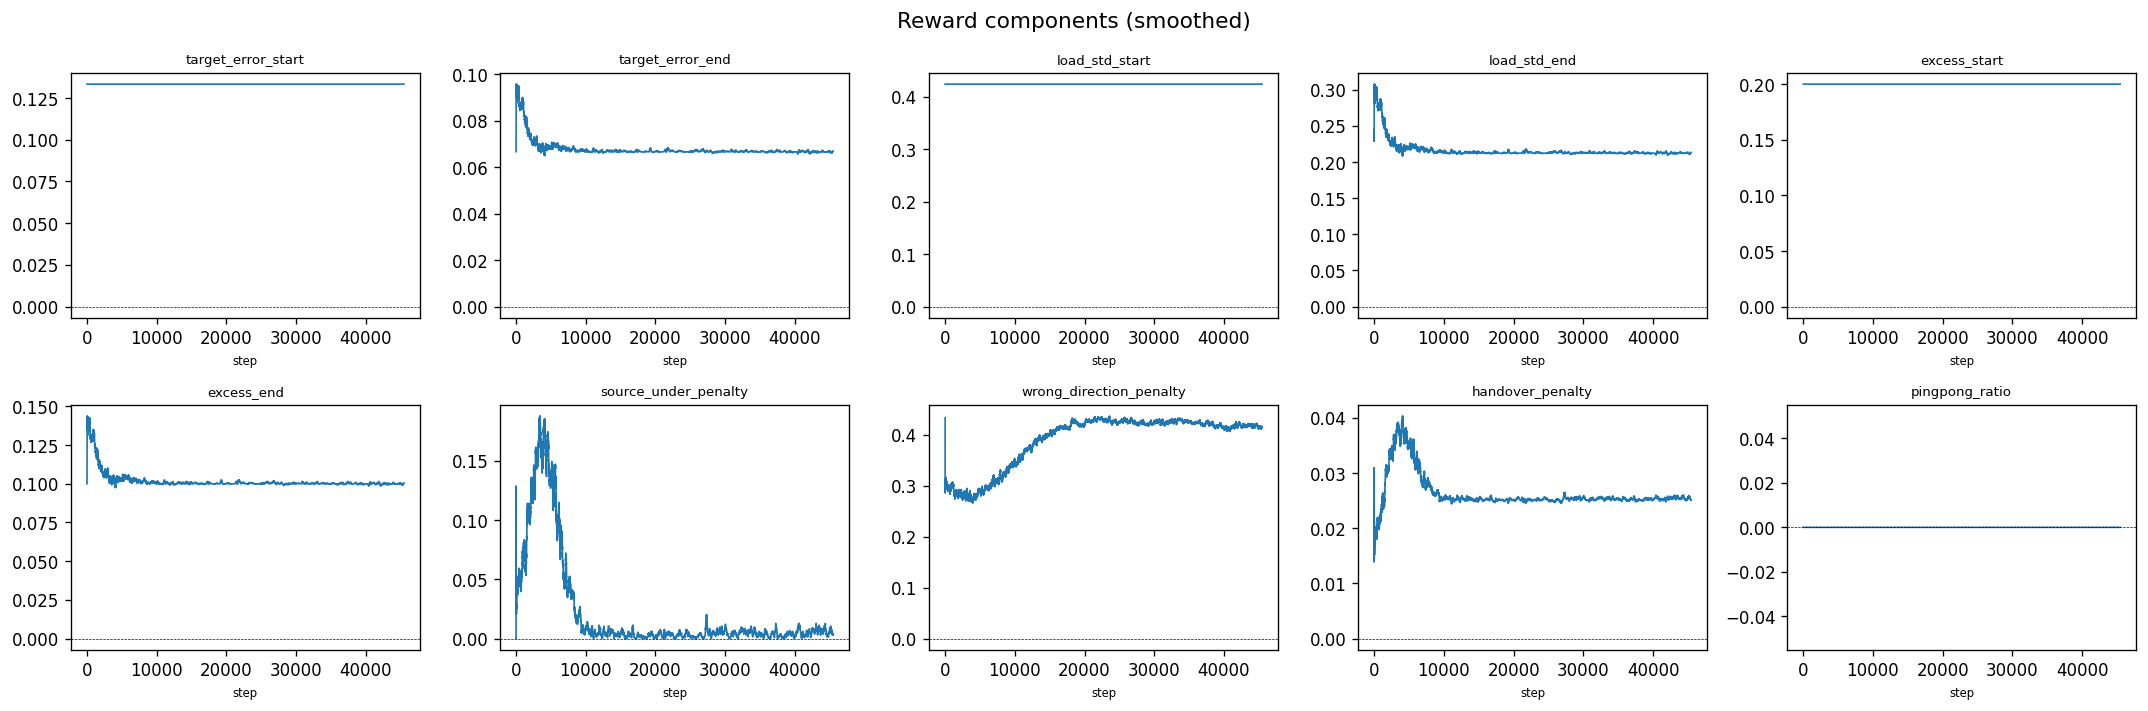

Component means (last 20 % of training):
  target_error_start            : 0.1333
  target_error_end              : 0.0667
  load_std_start                : 0.4243
  load_std_end                  : 0.2125
  excess_start                  : 0.2000
  excess_end                    : 0.1001
  source_under_penalty          : 0.0048
  wrong_direction_penalty       : 0.4181
  handover_penalty              : 0.0253
  pingpong_ratio                : 0.0000


In [3]:
comps = {
    'target_error_start':        df['paper_target_error_start'],
    'target_error_end':          df['paper_target_error_end'],
    'load_std_start':            df['paper_target_load_std_start'],
    'load_std_end':              df['paper_target_load_std_end'],
    'excess_start':              df['paper_target_excess_start'],
    'excess_end':                df['paper_target_excess_end'],
    'source_under_penalty':      df['paper_target_source_under_penalty'],
    'wrong_direction_penalty':   df['paper_target_wrong_direction_penalty'],
    'handover_penalty':          df['paper_target_handover_penalty'],
    'pingpong_ratio':            df['paper_target_pingpong_ratio'],
}

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
fig.suptitle('Reward components (smoothed)', fontsize=13)
for ax, (name, series) in zip(axes.flat, comps.items()):
    ax.plot(df['step'], smooth(series), lw=1)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel('step', fontsize=7)
    ax.axhline(0, color='k', lw=0.4, ls='--')
plt.tight_layout(); plt.show()

print('Component means (last 20 % of training):')
tail = df.iloc[int(len(df)*0.8):]
for name, series in comps.items():
    print(f'  {name:<30s}: {tail[series.name].mean():.4f}')

## 3 · Load distribution per gNB (demand)

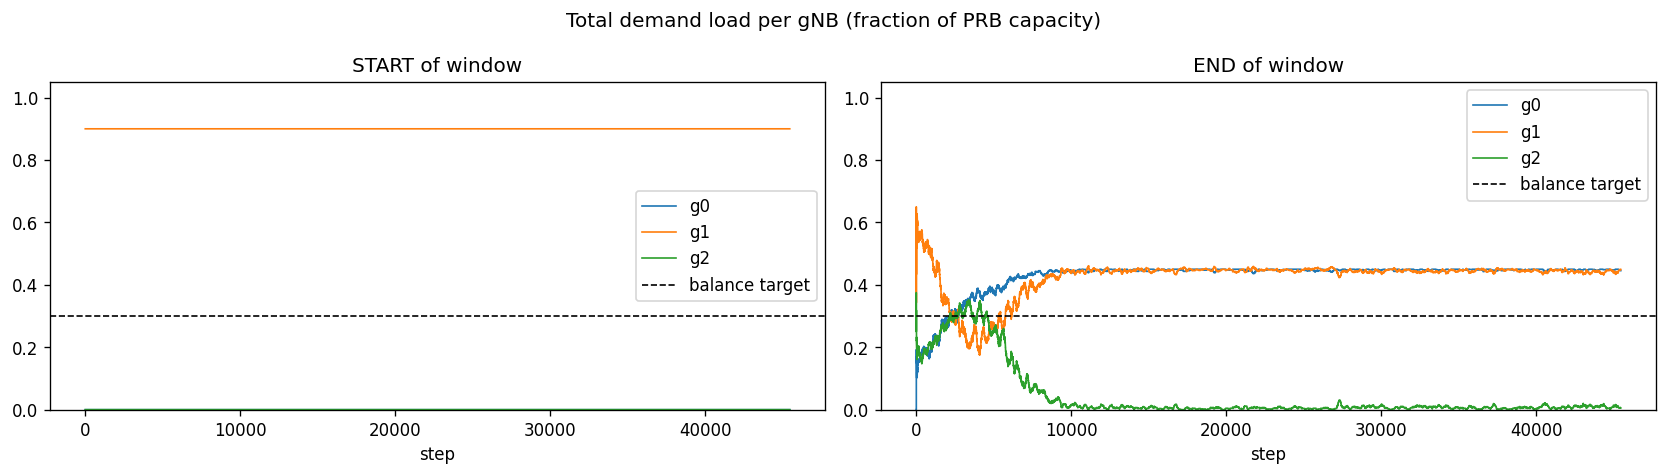

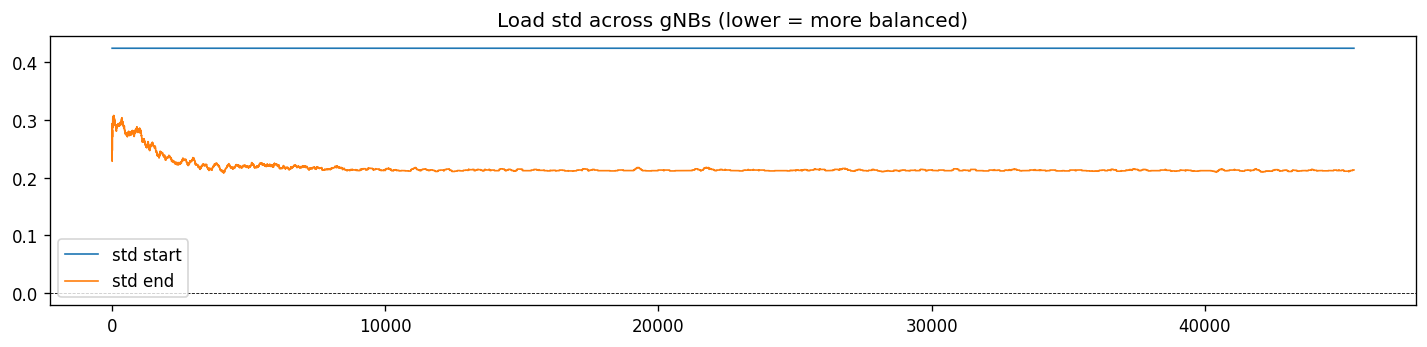

In [4]:
gnbs = ['g0', 'g1', 'g2']
colors = ['C0', 'C1', 'C2']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Total demand load per gNB (fraction of PRB capacity)')

for g, c in zip(gnbs, colors):
    axes[0].plot(df['step'], smooth(df[f'gnb_total_demand_load_start_{g}']), lw=1, color=c, label=g)
    axes[1].plot(df['step'], smooth(df[f'gnb_total_demand_load_end_{g}']), lw=1, color=c, label=g)

# balance target (should be equal across gNBs)
for ax, label in zip(axes, ['START of window', 'END of window']):
    ax.axhline(df['balance_target_g0_eMBB'].mean() + 
               df['balance_target_g0_URLLC'].mean() +
               df['balance_target_g0_mMTC'].mean(),
               color='k', lw=1, ls='--', label='balance target')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('step'); ax.set_title(label); ax.legend()

plt.tight_layout(); plt.show()

# Std of load across gNBs (imbalance metric)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(df['step'], smooth(df['gnb_total_demand_load_std_start']), label='std start', lw=1)
ax.plot(df['step'], smooth(df['gnb_total_demand_load_std_end']),   label='std end',   lw=1)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_title('Load std across gNBs (lower = more balanced)'); ax.legend()
plt.tight_layout(); plt.show()

## 4 · Per-slice demand load (gNB × slice)

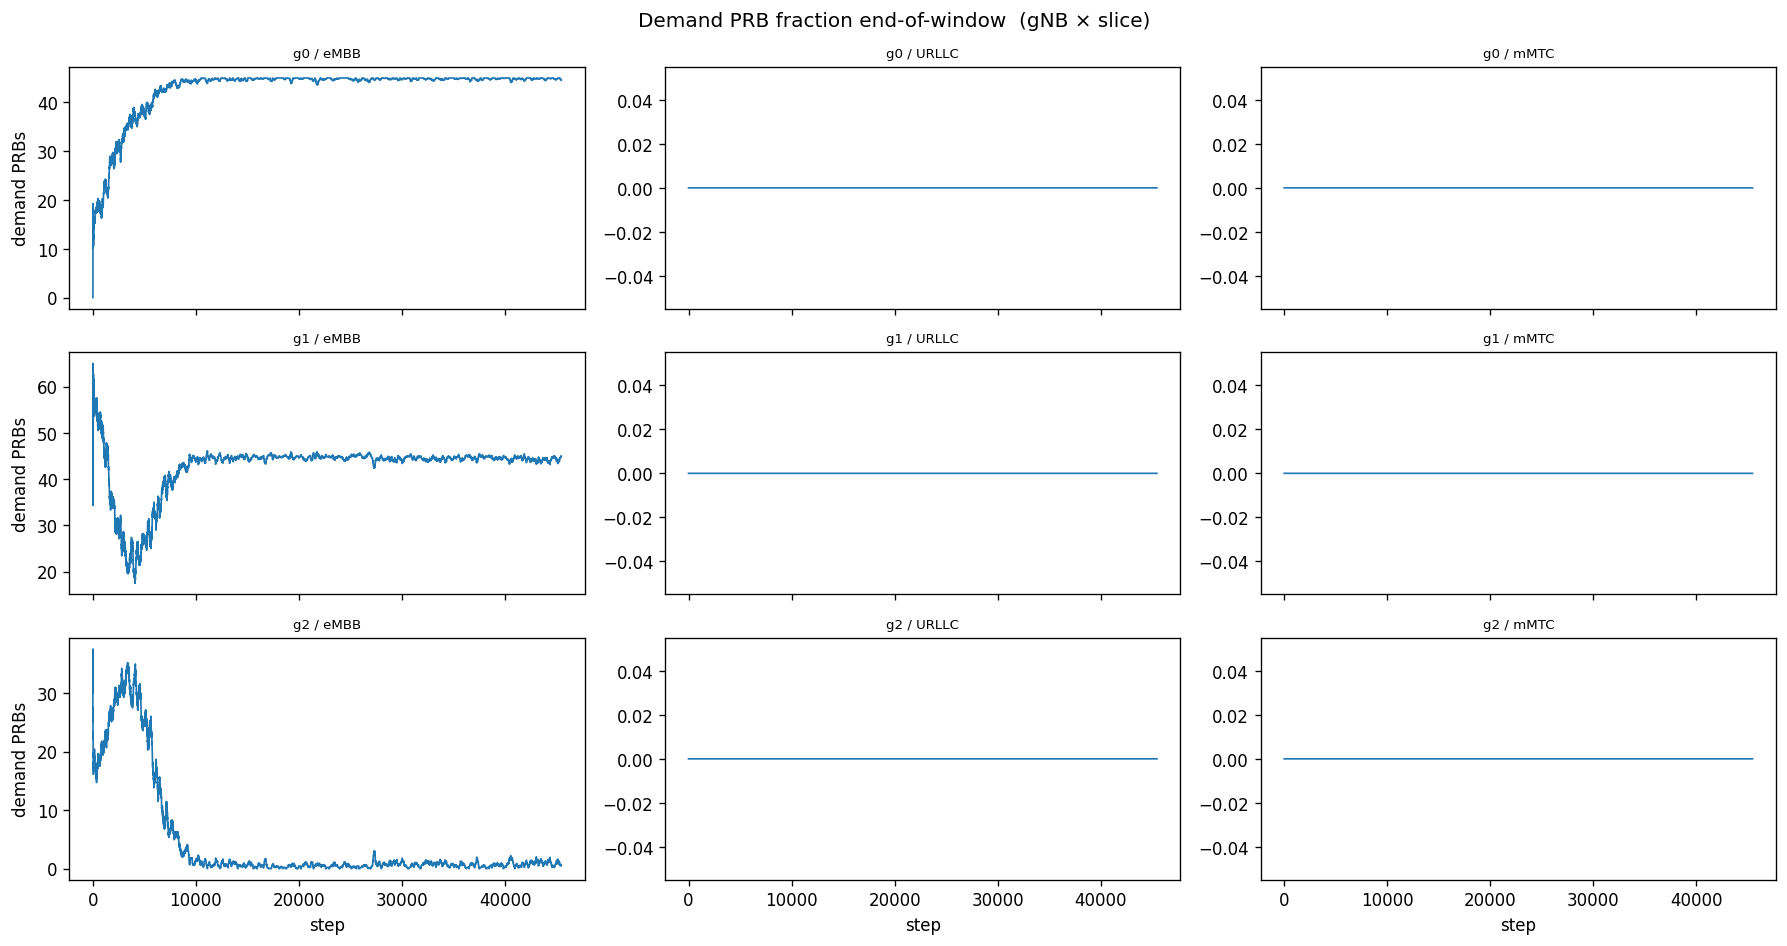

In [5]:
slices = ['eMBB', 'URLLC', 'mMTC']

fig, axes = plt.subplots(3, 3, figsize=(15, 8), sharex=True)
fig.suptitle('Demand PRB fraction end-of-window  (gNB × slice)', fontsize=12)

prb_cap = cfg.get('slice_prb_budgets', None)
# fallback: estimate from PRB counts
for r, g in enumerate(gnbs):
    for c, s in enumerate(slices):
        col = f'demand_prb_end_{g}_{s}'
        cap_col = f'used_prb_end_{g}_{s}'  # same capacity
        # normalize by network total for relative load
        axes[r, c].plot(df['step'], smooth(df[col]), lw=1)
        axes[r, c].set_title(f'{g} / {s}', fontsize=8)
        if c == 0: axes[r, c].set_ylabel('demand PRBs')
        if r == 2: axes[r, c].set_xlabel('step')

plt.tight_layout(); plt.show()

## 5 · Handover behaviour

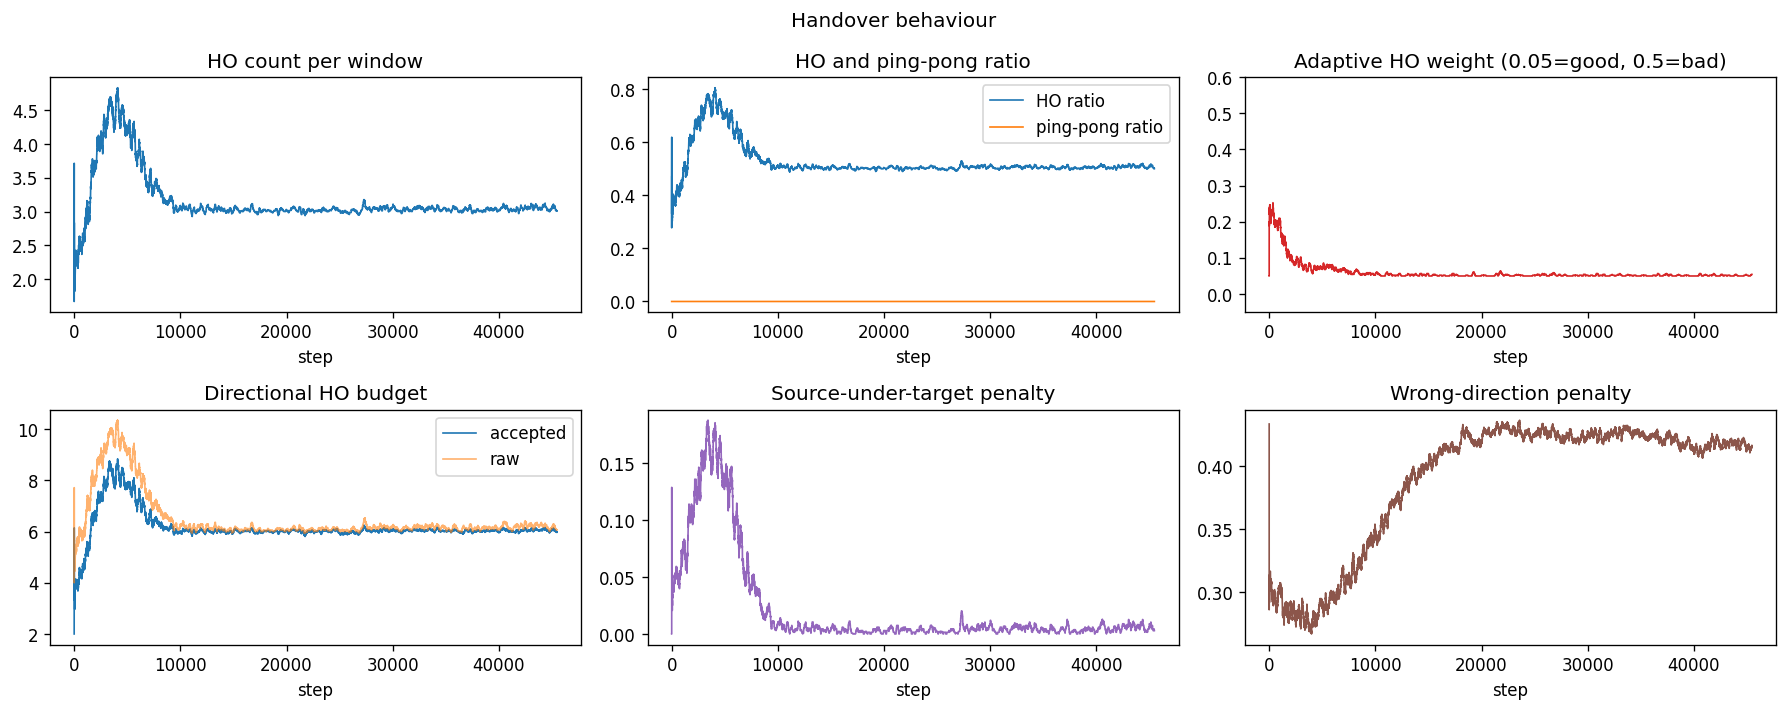

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
fig.suptitle('Handover behaviour', fontsize=12)

ax = axes[0, 0]
ax.plot(df['step'], smooth(df['handover_count']), lw=1)
ax.set_title('HO count per window'); ax.set_xlabel('step')

ax = axes[0, 1]
ax.plot(df['step'], smooth(df['paper_handover_ratio']),   lw=1, label='HO ratio')
ax.plot(df['step'], smooth(df['paper_pingpong_ratio']),   lw=1, label='ping-pong ratio')
ax.set_title('HO and ping-pong ratio'); ax.legend()

ax = axes[0, 2]
ax.plot(df['step'], smooth(df['paper_target_handover_weight']), lw=1, color='C3')
ax.set_ylim(-0.05, 0.6)
ax.set_title('Adaptive HO weight (0.05=good, 0.5=bad)')

ax = axes[1, 0]
ax.plot(df['step'], smooth(df['total_accepted_directional_budget']), lw=1, label='accepted')
ax.plot(df['step'], smooth(df['total_raw_directional_budget']),      lw=1, label='raw', alpha=0.6)
ax.set_title('Directional HO budget'); ax.legend()

ax = axes[1, 1]
ax.plot(df['step'], smooth(df['paper_target_source_under_penalty']), lw=1, color='C4')
ax.set_title('Source-under-target penalty')

ax = axes[1, 2]
ax.plot(df['step'], smooth(df['paper_target_wrong_direction_penalty']), lw=1, color='C5')
ax.set_title('Wrong-direction penalty')

for row in axes:
    for a in row:
        a.set_xlabel('step')
plt.tight_layout(); plt.show()

## 6 · Action bias (18 directional biases)

18 bias columns: ['bias_g0_to_g1_eMBB', 'bias_g0_to_g1_URLLC', 'bias_g0_to_g1_mMTC', 'bias_g0_to_g2_eMBB', 'bias_g0_to_g2_URLLC', 'bias_g0_to_g2_mMTC', 'bias_g1_to_g0_eMBB', 'bias_g1_to_g0_URLLC', 'bias_g1_to_g0_mMTC', 'bias_g1_to_g2_eMBB', 'bias_g1_to_g2_URLLC', 'bias_g1_to_g2_mMTC', 'bias_g2_to_g0_eMBB', 'bias_g2_to_g0_URLLC', 'bias_g2_to_g0_mMTC', 'bias_g2_to_g1_eMBB', 'bias_g2_to_g1_URLLC', 'bias_g2_to_g1_mMTC']


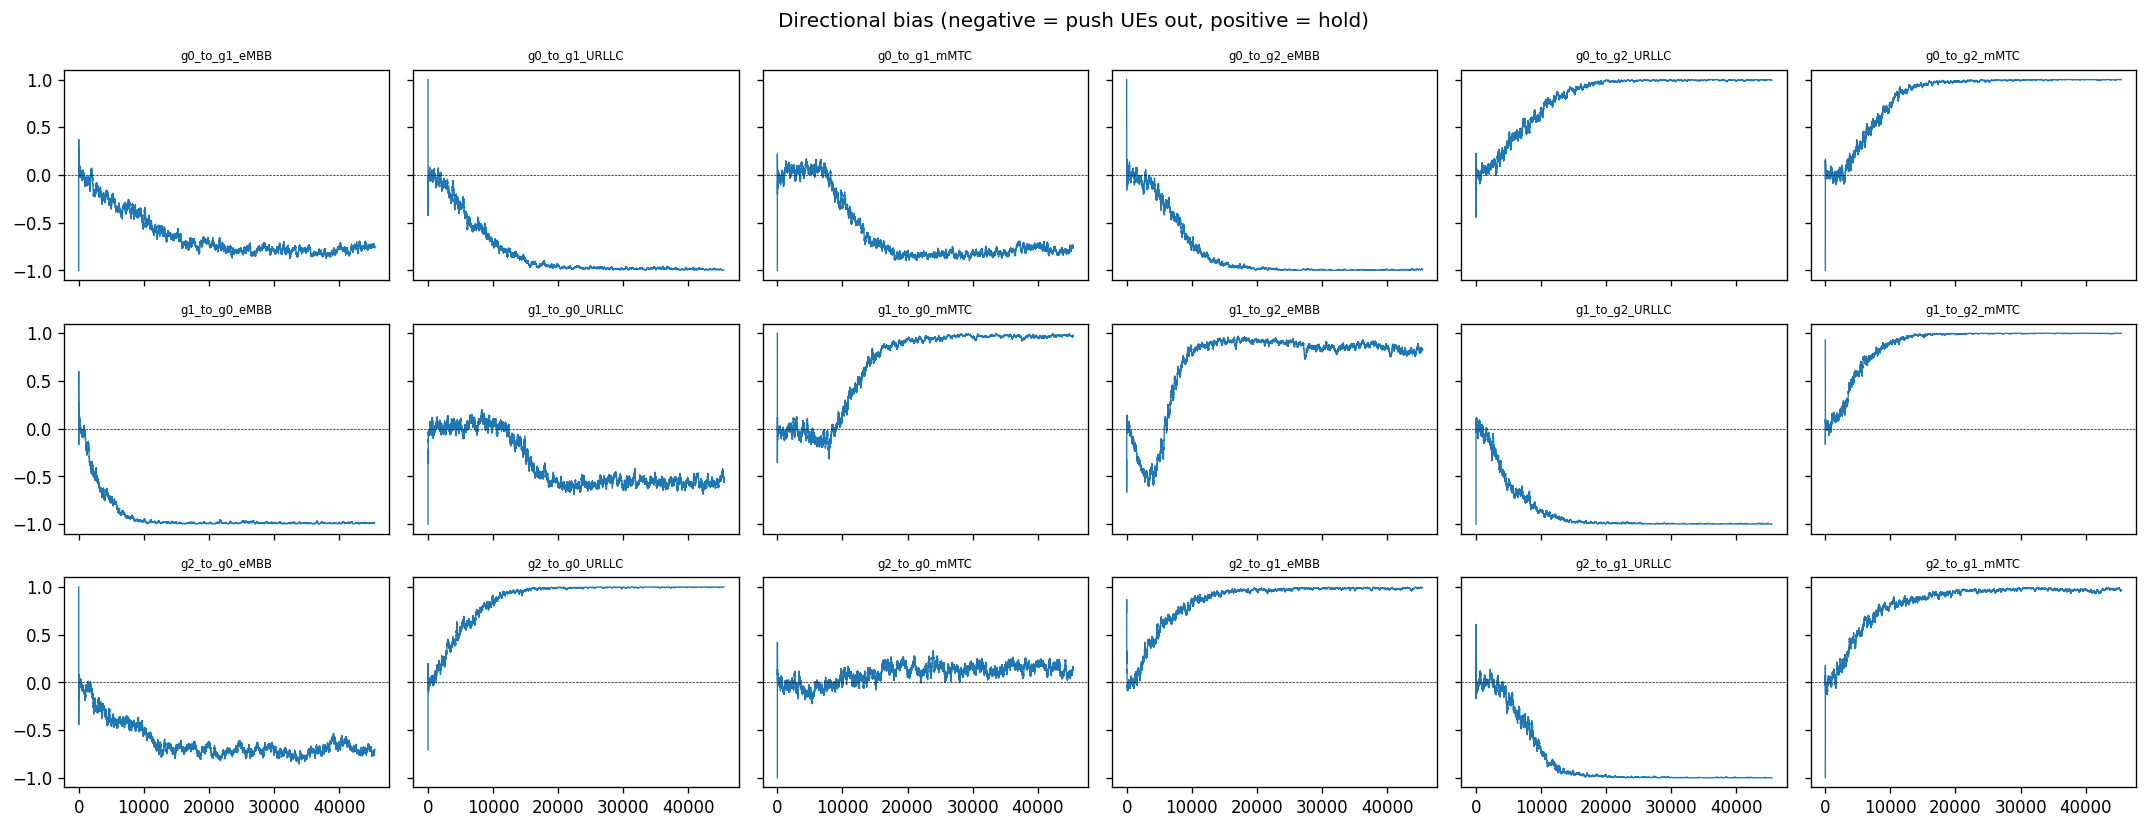


Bias means (last 20 %):
  bias_g0_to_g1_eMBB                 : -0.7837
  bias_g0_to_g1_URLLC                : -0.9872
  bias_g0_to_g1_mMTC                 : -0.7729
  bias_g0_to_g2_eMBB                 : -0.9947
  bias_g0_to_g2_URLLC                : 0.9937
  bias_g0_to_g2_mMTC                 : 0.9981
  bias_g1_to_g0_eMBB                 : -0.9892
  bias_g1_to_g0_URLLC                : -0.5634
  bias_g1_to_g0_mMTC                 : 0.9677
  bias_g1_to_g2_eMBB                 : 0.8396
  bias_g1_to_g2_URLLC                : -0.9975
  bias_g1_to_g2_mMTC                 : 0.9989
  bias_g2_to_g0_eMBB                 : -0.6826
  bias_g2_to_g0_URLLC                : 0.9977
  bias_g2_to_g0_mMTC                 : 0.1515
  bias_g2_to_g1_eMBB                 : 0.9847
  bias_g2_to_g1_URLLC                : -0.9985
  bias_g2_to_g1_mMTC                 : 0.9663


In [7]:
bias_cols = [c for c in df.columns if c.startswith('bias_')]
print(f'{len(bias_cols)} bias columns:', bias_cols)

fig, axes = plt.subplots(3, 6, figsize=(18, 7), sharex=True, sharey=True)
fig.suptitle('Directional bias (negative = push UEs out, positive = hold)', fontsize=12)

for ax, col in zip(axes.flat, bias_cols):
    ax.plot(df['step'], smooth(df[col]), lw=0.8)
    ax.axhline(0, color='k', lw=0.4, ls='--')
    ax.set_title(col.replace('bias_', ''), fontsize=7)
    ax.set_ylim(-1.1, 1.1)

# hide unused axes
for ax in axes.flat[len(bias_cols):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

print('\nBias means (last 20 %):')
tail = df.iloc[int(len(df)*0.8):]
for c in bias_cols:
    print(f'  {c:<35s}: {tail[c].mean():.4f}')

## 7 · Policy learning indicators

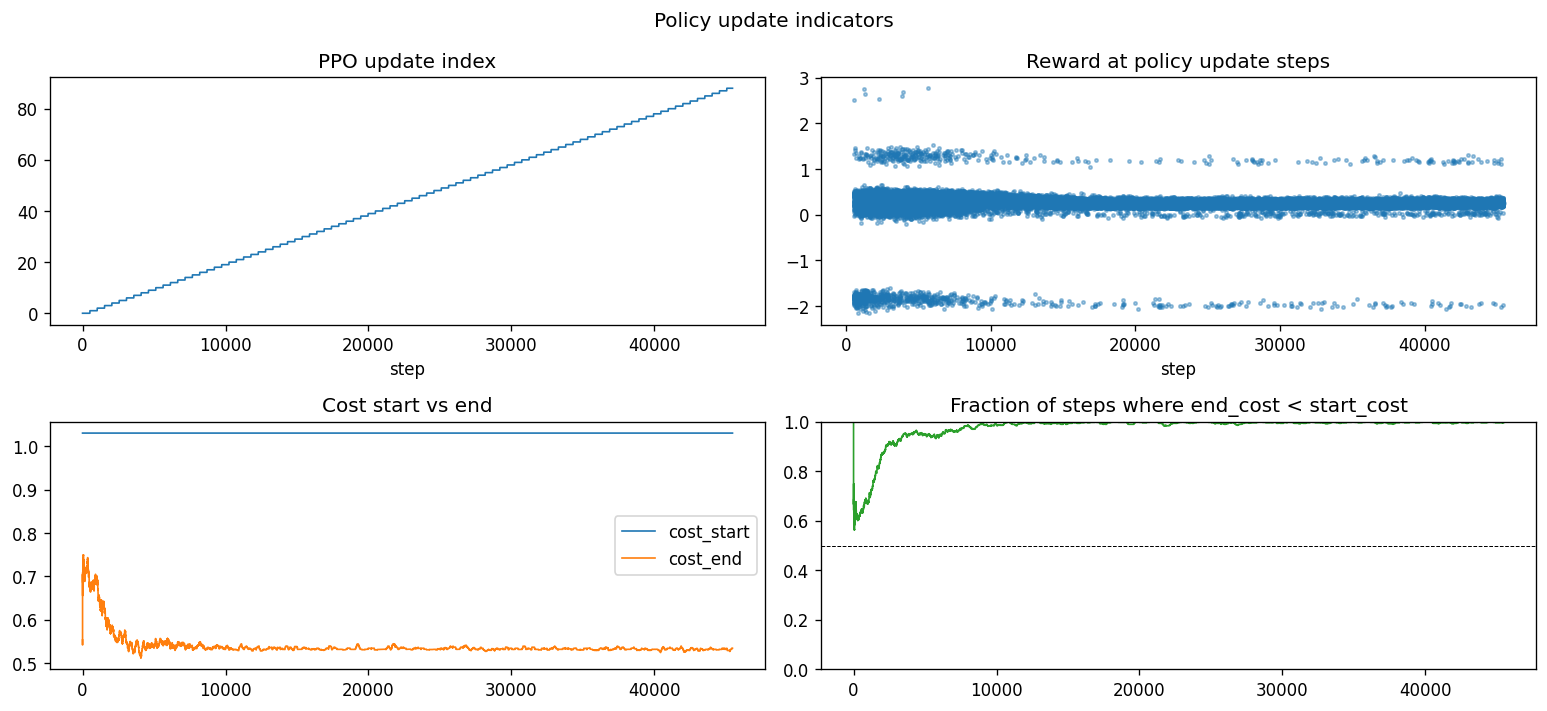

In [8]:
ppo_steps = df[df['policy_has_updated'] == 1]

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
fig.suptitle('Policy update indicators', fontsize=12)

ax = axes[0, 0]
ax.plot(df['step'], df['ppo_update_index'], lw=1)
ax.set_title('PPO update index'); ax.set_xlabel('step')

ax = axes[0, 1]
# reward before and after each update
update_steps = ppo_steps['step'].values
reward_at_update = ppo_steps['reward'].values
ax.scatter(update_steps, reward_at_update, s=4, alpha=0.4)
ax.set_title('Reward at policy update steps'); ax.set_xlabel('step')

ax = axes[1, 0]
ax.plot(df['step'], smooth(df['paper_target_cost_start']), label='cost_start', lw=1)
ax.plot(df['step'], smooth(df['paper_target_cost_end']),   label='cost_end',   lw=1)
ax.set_title('Cost start vs end'); ax.legend()

ax = axes[1, 1]
frac_better = smooth((df['paper_target_cost_end'] < df['paper_target_cost_start']).astype(float), 500)
ax.plot(df['step'], frac_better, lw=1, color='C2')
ax.axhline(0.5, color='k', lw=0.6, ls='--')
ax.set_ylim(0, 1)
ax.set_title('Fraction of steps where end_cost < start_cost')

plt.tight_layout(); plt.show()

## 8 · Target error vs balance target

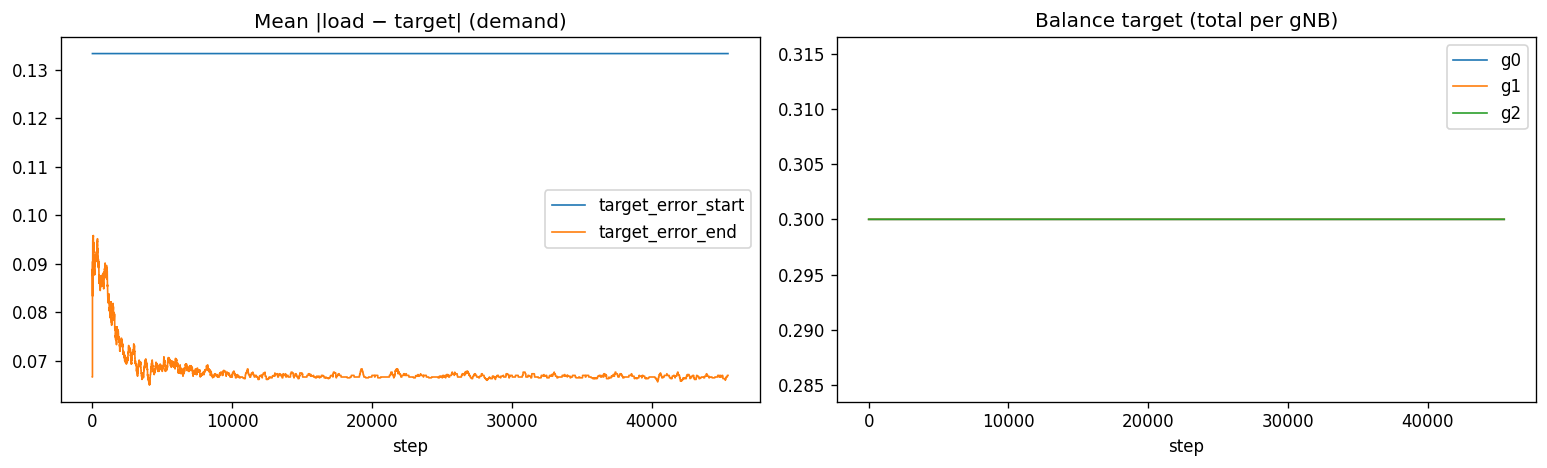

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(df['step'], smooth(df['paper_target_error_start']), lw=1, label='target_error_start')
ax.plot(df['step'], smooth(df['paper_target_error_end']),   lw=1, label='target_error_end')
ax.set_title('Mean |load − target| (demand)'); ax.legend()
ax.set_xlabel('step')

ax = axes[1]
# balance target values over time (should be constant per scenario)
for g in gnbs:
    total_bt = sum(df[f'balance_target_{g}_{s}'] for s in slices)
    ax.plot(df['step'], smooth(total_bt), lw=1, label=g)
ax.set_title('Balance target (total per gNB)'); ax.legend()
ax.set_xlabel('step')

plt.tight_layout(); plt.show()

## 9 · SLA and overload

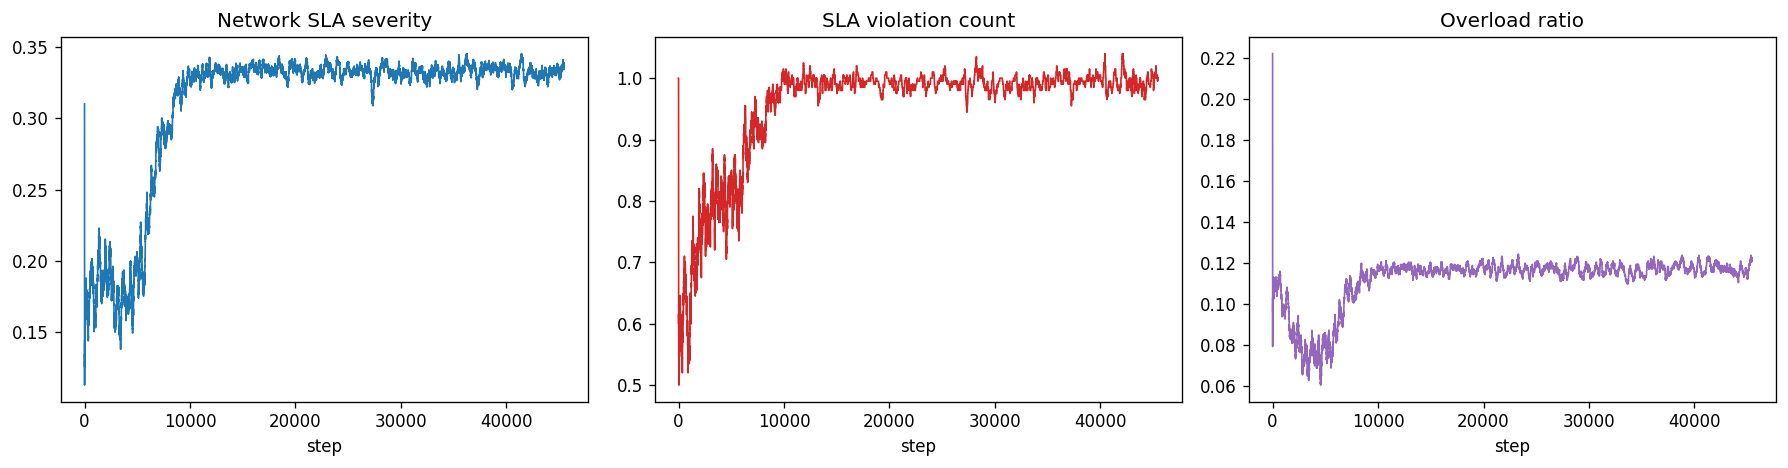

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df['step'], smooth(df['sla_severity']), lw=1)
axes[0].set_title('Network SLA severity'); axes[0].set_xlabel('step')

axes[1].plot(df['step'], smooth(df['sla_count']), lw=1, color='C3')
axes[1].set_title('SLA violation count'); axes[1].set_xlabel('step')

axes[2].plot(df['step'], smooth(df['overload_ratio']), lw=1, color='C4')
axes[2].set_title('Overload ratio'); axes[2].set_xlabel('step')

plt.tight_layout(); plt.show()

## 10 · Episode-level statistics

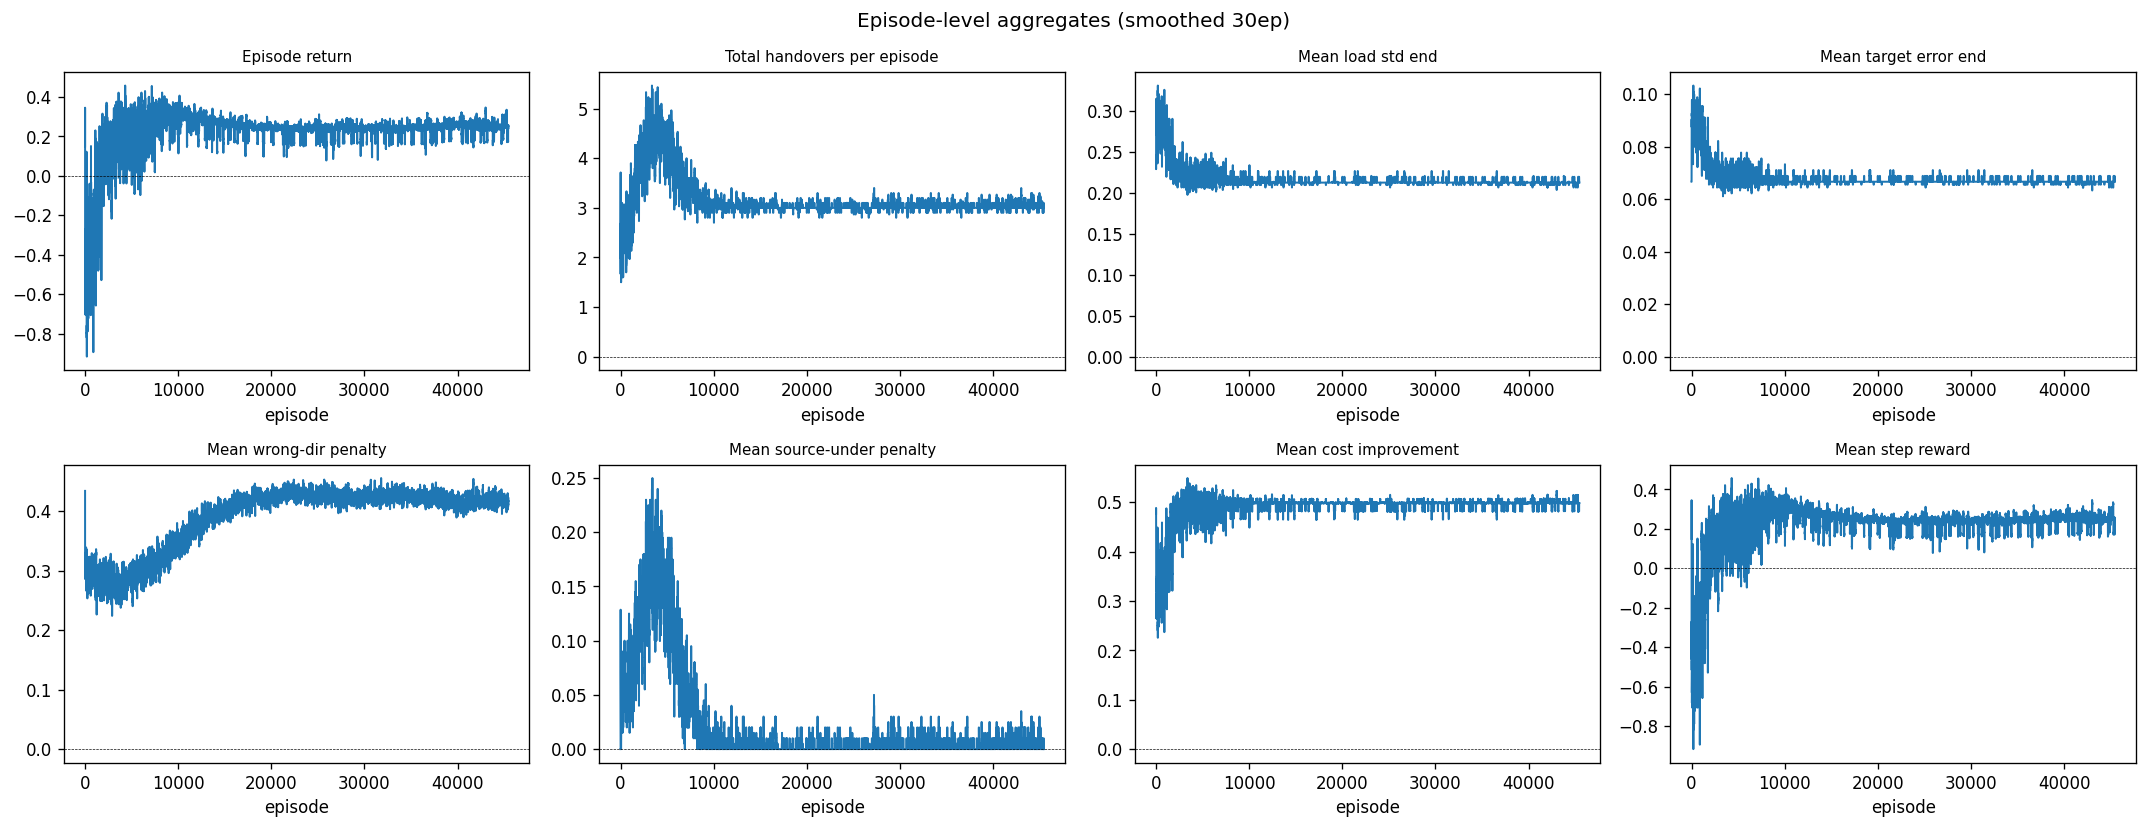

In [11]:
ep = df.groupby('episode').agg(
    ep_return         = ('episode_return', 'last'),
    mean_reward       = ('reward', 'mean'),
    total_ho          = ('handover_count', 'sum'),
    mean_std_end      = ('gnb_total_demand_load_std_end', 'mean'),
    mean_target_err   = ('paper_target_error_end', 'mean'),
    mean_wrong_dir    = ('paper_target_wrong_direction_penalty', 'mean'),
    mean_src_under    = ('paper_target_source_under_penalty', 'mean'),
    mean_cost_impr    = ('paper_target_cost_improvement', 'mean'),
).reset_index()

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('Episode-level aggregates (smoothed 30ep)', fontsize=12)

def ep_smooth(s, w=30): return s.rolling(w, min_periods=1).mean()

pairs = [
    ('ep_return',       'Episode return'),
    ('total_ho',        'Total handovers per episode'),
    ('mean_std_end',    'Mean load std end'),
    ('mean_target_err', 'Mean target error end'),
    ('mean_wrong_dir',  'Mean wrong-dir penalty'),
    ('mean_src_under',  'Mean source-under penalty'),
    ('mean_cost_impr',  'Mean cost improvement'),
    ('mean_reward',     'Mean step reward'),
]
for ax, (col, title) in zip(axes.flat, pairs):
    ax.plot(ep['episode'], ep_smooth(ep[col]), lw=1.2)
    ax.axhline(0, color='k', lw=0.4, ls='--')
    ax.set_title(title, fontsize=9); ax.set_xlabel('episode')

plt.tight_layout(); plt.show()

## 11 · Directional budget vs executed HO

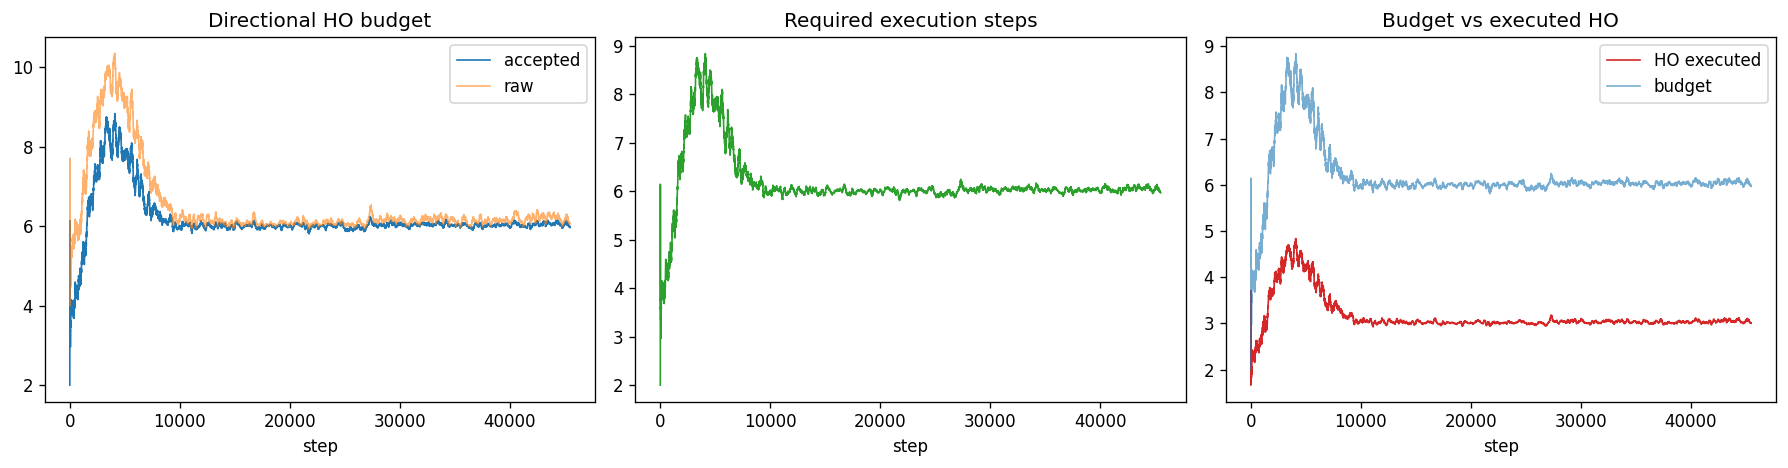

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(df['step'], smooth(df['total_accepted_directional_budget']), lw=1, label='accepted')
ax.plot(df['step'], smooth(df['total_raw_directional_budget']),      lw=1, label='raw', alpha=0.6)
ax.set_title('Directional HO budget'); ax.legend()

ax = axes[1]
ax.plot(df['step'], smooth(df['dynamic_required_execution_steps']), lw=1, color='C2')
ax.set_title('Required execution steps')

ax = axes[2]
ax.plot(df['step'], smooth(df['handover_count']), lw=1, color='C3', label='HO executed')
ax.plot(df['step'], smooth(df['total_accepted_directional_budget']), lw=1, color='C0',
        alpha=0.6, label='budget')
ax.set_title('Budget vs executed HO'); ax.legend()

for a in axes: a.set_xlabel('step')
plt.tight_layout(); plt.show()

## 12 · UE counts per gNB (load migration evidence)

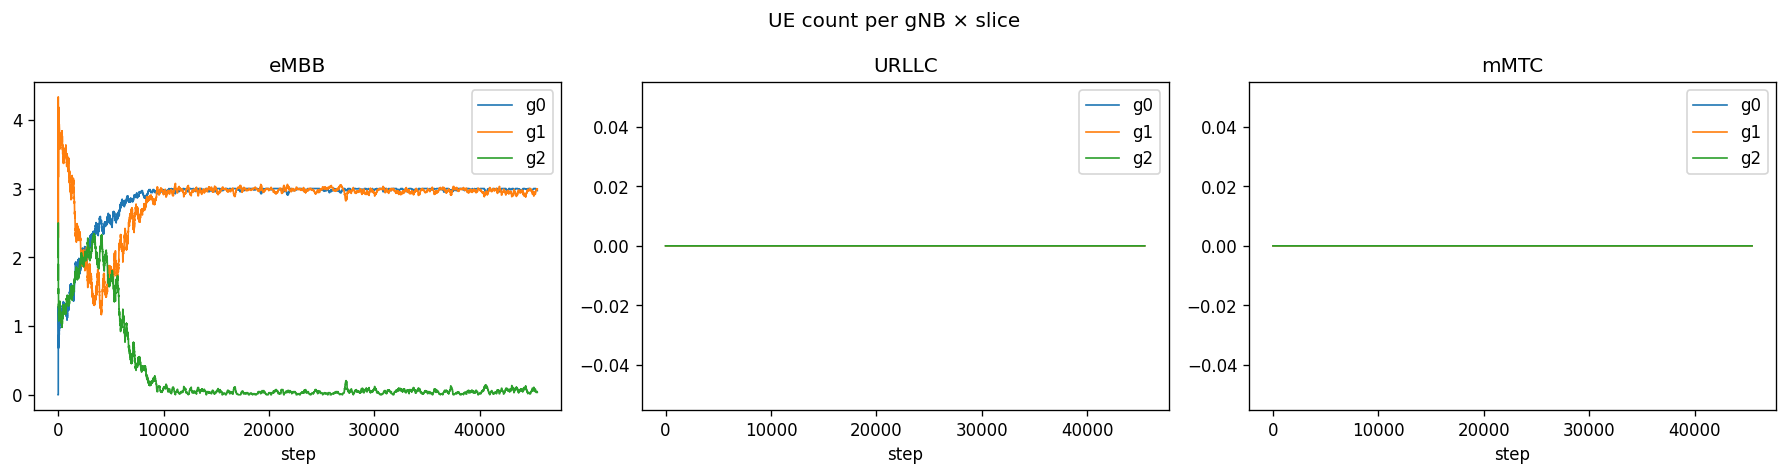

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle('UE count per gNB × slice')

for ax, s in zip(axes, slices):
    for g, c in zip(gnbs, colors):
        ax.plot(df['step'], smooth(df[f'ue_count_{g}_{s}']), lw=1, color=c, label=g)
    ax.set_title(s); ax.set_xlabel('step'); ax.legend()

plt.tight_layout(); plt.show()

## 13 · Summary statistics

In [14]:
tail = df.iloc[int(len(df) * 0.8):]

summary = {
    'reward (mean)':                 tail['reward'].mean(),
    'reward (std)':                  tail['reward'].std(),
    'paper_target_reward (mean)':    tail['paper_target_reward'].mean(),
    'cost_improvement (mean)':       tail['paper_target_cost_improvement'].mean(),
    'target_error_end (mean)':       tail['paper_target_error_end'].mean(),
    'load_std_end (mean)':           tail['paper_target_load_std_end'].mean(),
    'excess_end (mean)':             tail['paper_target_excess_end'].mean(),
    'wrong_dir_penalty (mean)':      tail['paper_target_wrong_direction_penalty'].mean(),
    'src_under_penalty (mean)':      tail['paper_target_source_under_penalty'].mean(),
    'HO count per window (mean)':    tail['handover_count'].mean(),
    'pingpong_ratio (mean)':         tail['paper_target_pingpong_ratio'].mean(),
    'overload_ratio (mean)':         tail['overload_ratio'].mean(),
    'sla_severity (mean)':           tail['sla_severity'].mean(),
    'frac steps cost improved':      (tail['paper_target_cost_end'] < tail['paper_target_cost_start']).mean(),
}

print('=== Last 20% of training (steps) ===')
for k, v in summary.items():
    print(f'  {k:<40s}: {v:.4f}')

=== Last 20% of training (steps) ===
  reward (mean)                           : 0.2471
  reward (std)                            : 0.1570
  paper_target_reward (mean)              : 0.2471
  cost_improvement (mean)                 : 0.4980
  target_error_end (mean)                 : 0.0667
  load_std_end (mean)                     : 0.2125
  excess_end (mean)                       : 0.1001
  wrong_dir_penalty (mean)                : 0.4181
  src_under_penalty (mean)                : 0.0048
  HO count per window (mean)              : 3.0385
  pingpong_ratio (mean)                   : 0.0000
  overload_ratio (mean)                   : 0.1176
  sla_severity (mean)                     : 0.3331
  frac steps cost improved                : 0.9965


## 14 · Config used

In [15]:
key_cfg = [
    'upper_reward_mode', 'single_training_scenario', 'total_timesteps',
    'ppo_n_steps', 'ppo_batch_size', 'learning_rate',
    'local_steps_per_global', 'global_steps_per_episode',
    'post_handover_settle_steps', 'max_handovers_per_local_step',
    'safe_admission', 'dynamic_upper_window', 'max_dynamic_local_steps_per_global',
    'seed',
]
for k in key_cfg:
    print(f'  {k:<42s}: {cfg.get(k, "N/A")}')

  upper_reward_mode                         : paper_cost_target_delta
  single_training_scenario                  : jain_balance_controllable
  total_timesteps                           : 50000
  ppo_n_steps                               : 512
  ppo_batch_size                            : 128
  learning_rate                             : 0.0003
  local_steps_per_global                    : 10
  global_steps_per_episode                  : 12
  post_handover_settle_steps                : 4
  max_handovers_per_local_step              : 1
  safe_admission                            : True
  dynamic_upper_window                      : N/A
  max_dynamic_local_steps_per_global        : N/A
  seed                                      : 7
